# Inferencia en CPU — modelo entrenado de clasificación de defectos

Este notebook demuestra que el modelo entrenado **funciona sin GPU**:

1. Carga el checkpoint de **MobileNetV3-Small** (mejor modelo del experimento:
   F1 = 1.0000 en test, 1.5M parámetros) con `map_location="cpu"`.
2. Corre inferencia sobre imágenes del conjunto de **test** (que no participó
   en el entrenamiento).
3. Visualiza las predicciones con su confianza.

No requiere CUDA ni MPS: todo se ejecuta en el procesador.

## 1. Configuración e imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

# Rutas relativas: el notebook vive en notebooks/ dentro del repositorio.
ROOT = Path("..").resolve()

# Se reutiliza exactamente la misma lógica del entrenamiento (src/common.py).
sys.path.insert(0, str(ROOT / "src"))

from common import (  # noqa: E402
    IMAGENET_MEAN,
    IMAGENET_STD,
    load_checkpoint,
    make_eval_transform,
)

# Se fuerza CPU explícitamente, aunque haya GPU disponible.
DEVICE = torch.device("cpu")

CHECKPOINT_PATH = (
    ROOT / "outputs" / "checkpoints" / "mobilenet_v3_small_best.pt"
)
TEST_DIR = ROOT / "industrial_defect_dataset" / "test"

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Dispositivo de inferencia:", DEVICE)

PyTorch: 2.13.0+cu130
CUDA disponible: False
Dispositivo de inferencia: cpu


## 2. Carga del modelo entrenado

El checkpoint se carga con `map_location="cpu"`, por lo que un modelo
entrenado en GPU se puede usar en cualquier máquina sin GPU.

In [2]:
model, checkpoint = load_checkpoint(CHECKPOINT_PATH, DEVICE)

CLASS_NAMES = checkpoint["class_names"]
IMG_SIZE = checkpoint["img_size"]

print("Modelo:", checkpoint["model_name"])
print("Clases:", CLASS_NAMES)
print("Métricas de validación guardadas en el checkpoint:")
for nombre, valor in checkpoint["metrics"].items():
    print(f"  {nombre}: {valor:.4f}")

Modelo: mobilenet_v3_small
Clases: ['crack', 'hole', 'normal', 'rust', 'scratch']
Métricas de validación guardadas en el checkpoint:
  accuracy: 1.0000
  f1_macro: 1.0000
  f1_weighted: 1.0000


## 3. Inferencia sobre imágenes de test

Se toman 2 imágenes por clase del conjunto de **test** (selección
determinista con semilla fija) y se clasifican en CPU.

In [3]:
transform = make_eval_transform(IMG_SIZE)

rng = np.random.default_rng(42)

muestras = []
for clase in CLASS_NAMES:
    imagenes = sorted((TEST_DIR / clase).glob("*.png"))
    seleccionadas = rng.choice(imagenes, size=2, replace=False)
    for ruta in seleccionadas:
        muestras.append((clase, Path(str(ruta))))

print(f"Imágenes de prueba: {len(muestras)}")

Imágenes de prueba: 10


In [4]:
@torch.no_grad()
def predecir(ruta_imagen):
    img = Image.open(ruta_imagen)
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    probs = torch.softmax(model(tensor), dim=1).numpy()[0]
    idx = int(probs.argmax())
    return CLASS_NAMES[idx], float(probs[idx]), img


resultados = []
for real, ruta in muestras:
    prediccion, confianza, img = predecir(ruta)
    resultados.append({
        "ruta": ruta,
        "real": real,
        "prediccion": prediccion,
        "confianza": confianza,
        "imagen": img,
    })
    marca = "OK" if prediccion == real else "ERROR"
    print(
        f"{ruta.name:22s} real={real:8s} "
        f"prediccion={prediccion:8s} confianza={confianza:.3f} [{marca}]"
    )

crack_00252.png        real=crack    prediccion=crack    confianza=1.000 [OK]
crack_02374.png        real=crack    prediccion=crack    confianza=1.000 [OK]
hole_01325.png         real=hole     prediccion=hole     confianza=1.000 [OK]
hole_01321.png         real=hole     prediccion=hole     confianza=1.000 [OK]


normal_02084.png       real=normal   prediccion=normal   confianza=0.962 [OK]
normal_00285.png       real=normal   prediccion=normal   confianza=0.999 [OK]
rust_00293.png         real=rust     prediccion=rust     confianza=1.000 [OK]
rust_01420.png         real=rust     prediccion=rust     confianza=1.000 [OK]
scratch_02123.png      real=scratch  prediccion=scratch  confianza=1.000 [OK]
scratch_02236.png      real=scratch  prediccion=scratch  confianza=1.000 [OK]


## 4. Visualización de las predicciones

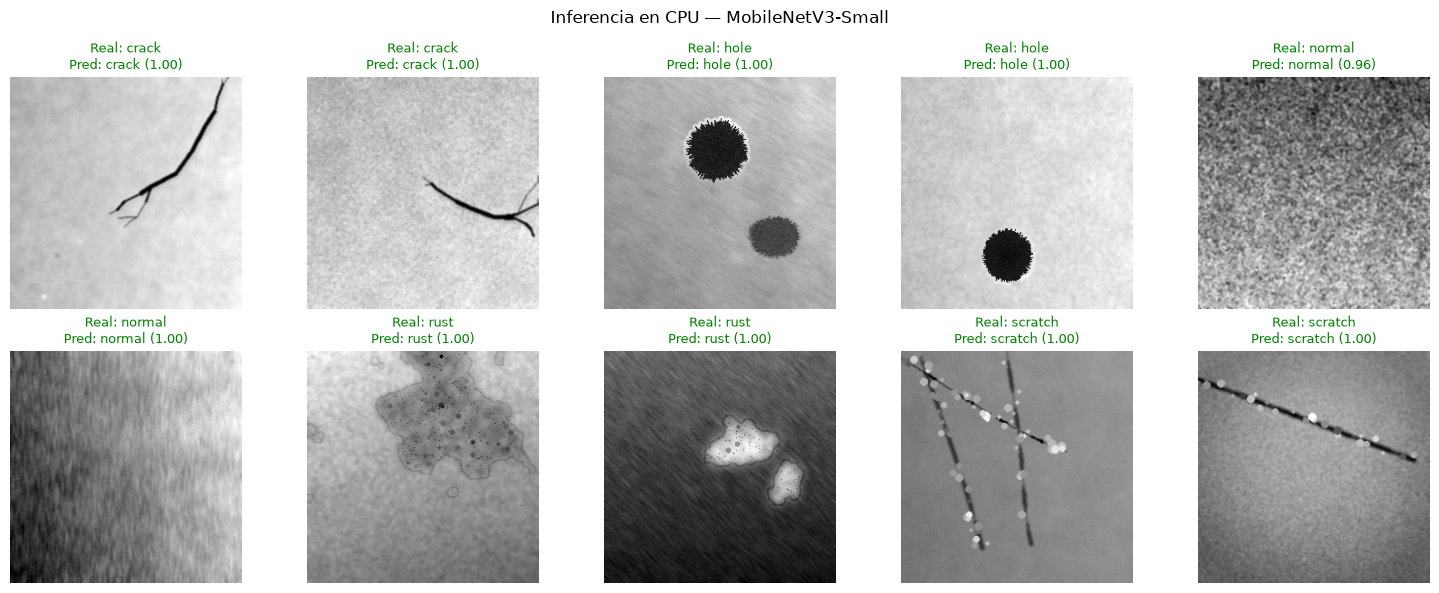

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, r in zip(axes.ravel(), resultados):
    ax.imshow(r["imagen"], cmap="gray")
    correcto = r["prediccion"] == r["real"]
    color = "green" if correcto else "red"
    ax.set_title(
        f"Real: {r['real']}\nPred: {r['prediccion']} ({r['confianza']:.2f})",
        fontsize=9,
        color=color,
    )
    ax.axis("off")

plt.suptitle("Inferencia en CPU — MobileNetV3-Small")
plt.tight_layout()
plt.show()

## 5. Conclusión

El modelo corre íntegramente en CPU: carga de pesos con
`map_location="cpu"`, preprocesamiento idéntico al del entrenamiento
(`src/common.py`) y predicción correcta sobre imágenes nunca vistas.

Para inferencia desde la línea de comandos (también CPU por defecto):

```bash
python src/predict.py --modelo outputs/checkpoints/mobilenet_v3_small_best.pt \
    --imagen industrial_defect_dataset/test/crack/
```